In [3]:
# CELL 1: Install Required Libraries
!pip install -q ultralytics
!pip install -q albumentations opencv-python clearml wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00a 0:00:01


In [4]:
# CELL 2: Imports and Reproducibility Setup
import os
import cv2
import json
import yaml
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from glob import glob
from ultralytics import YOLO

# Ensure reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # CuDNN benchmark for optimal performance on fixed sizes, deterministic for reproducibility
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

# Check Kaggle Dual T4 GPU setup
num_gpus = torch.cuda.device_count()
print(f"[*] Medical Deep Learning Environment Ready.")
print(f"[*] PyTorch Version: {torch.__version__}")
print(f"[*] GPUs Available: {num_gpus}")
if num_gpus > 0:
    for i in range(num_gpus):
        print(f"    - GPU {i}: {torch.cuda.get_device_name(i)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[*] Medical Deep Learning Environment Ready.
[*] PyTorch Version: 2.10.0+cu128
[*] GPUs Available: 2
    - GPU 0: Tesla T4
    - GPU 1: Tesla T4


In [15]:
# CELL 3: Configuration
BASE_DIR = "/kaggle/working"

# Your provided dataset paths
DATASET_PATH = "/kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed"
TRAIN_IMAGES = "/kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed/images/train"
VAL_IMAGES = "/kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed/images/val"

YAML_PATH = os.path.join(BASE_DIR, "spine_keypoints.yaml")

# Define keypoint shape: 4 keypoints per vertebra, 2 values per keypoint (x, y)
KPT_SHAPE = [4, 2]  # <--- THIS IS THE FIX
CLASSES = ['vertebra']

In [7]:
# CELL 4: CLAHE Preprocessing Function
def apply_clahe_to_image(image_path, output_path, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) 
    to enhance bone structures in spine X-rays.
    """
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error reading {image_path}")
        return
    
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    cl_img = clahe.apply(img)
    
    # Convert back to 3 channels (YOLO expects 3-channel inputs by default)
    cl_img_3c = cv2.cvtColor(cl_img, cv2.COLOR_GRAY2BGR)
    
    # Save processed image
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, cl_img_3c)

# Note: Once you provide the path, we will write a quick loop to run this on your 2000 images 
# and save them to a /kaggle/working/processed_dataset folder.

In [17]:
# CELL 5: Create data.yaml for YOLOv8-Pose
def create_yaml(yaml_output_path):
    dataset_config = {
        'path': DATASET_PATH,  # Base path pointing to your input data
        'train': TRAIN_IMAGES, # Absolute path to train images
        'val': VAL_IMAGES,     # Absolute path to val images
        'nc': len(CLASSES),
        'names': CLASSES,
        'kpt_shape': KPT_SHAPE # [4, 3] -> 4 corners, (x, y, visible)
    }
    
    with open(yaml_output_path, 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)
        
    print(f"[*] Created YOLOv8-Pose configuration at: {yaml_output_path}")

# Execute the function to generate the file
create_yaml(YAML_PATH)

[*] Created YOLOv8-Pose configuration at: /kaggle/working/spine_keypoints.yaml


In [18]:
# CELL 6: Training V1 - YOLOv8n-pose
def train_version_1(yaml_file):
    print("==========================================================")
    print("🚀 STARTING TRAINING: VERSION 1 (BASELINE YOLOv8n-pose)")
    print("==========================================================")

    # Initialize YOLOv8 Nano Pose model
    model = YOLO('yolov8n-pose.pt')

    # ---------------------------------------------------------
    # MEDICAL AUGMENTATION & TRAINING CONFIGURATION
    # ---------------------------------------------------------
    results = model.train(
        data=yaml_file,
        epochs=30,
        imgsz=512,
        batch=32,
        device=[0, 1] if torch.cuda.device_count() > 1 else 0,
        workers=4,
        amp=True,
        project='Scoliosis_Detection',
        name='v1_yolov8n_baseline',
        optimizer='AdamW',
        lr0=0.001,
        cos_lr=True,
        # STRICT MEDICAL AUGMENTATIONS
        hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
        degrees=10.0,
        translate=0.1,
        scale=0.1,
        shear=0.0,
        perspective=0.0,
        fliplr=0.0,  # NO HORIZONTAL FLIP
        flipud=0.0,
        mosaic=0.0,
        mixup=0.0,
        save=True,
        save_period=5,
        plots=True
    )
    return model, results

# Make sure these lines below are flush to the left margin!
v1_model, v1_results = train_version_1(YAML_PATH)

🚀 STARTING TRAINING: VERSION 1 (BASELINE YOLOv8n-pose)
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/spine_keypoints.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, mo

In [21]:
# CELL 7: Inference & Backend-Ready JSON Formatter
def predict_and_format(image_path, model, conf_thresh=0.5):
    """
    Runs YOLOv8-Pose inference and formats output into structured JSON.
    Automatically sorts vertebrae top-to-bottom based on Y-coordinates.
    """
    # Run inference
    results = model.predict(source=image_path, conf=conf_thresh, save=False)[0]
    
    # Extract Bounding Boxes and Keypoints
    boxes = results.boxes.xyxy.cpu().numpy()      # [N, 4]
    keypoints = results.keypoints.xy.cpu().numpy() # [N, 4, 2] (ignoring visibility for JSON)
    
    if len(boxes) == 0:
        return json.dumps({"error": "No vertebrae detected", "data": []}, indent=4)
    
    # Combine into a list of dictionaries for sorting
    detections = []
    for i in range(len(boxes)):
        # Calculate center Y of bounding box to sort vertebrae top-to-bottom
        center_y = (boxes[i][1] + boxes[i][3]) / 2.0
        
        detections.append({
            "center_y": center_y,
            "bbox": [float(val) for val in boxes[i]],
            "keypoints": [[float(kp[0]), float(kp[1])] for kp in keypoints[i]]
        })
    
    # Sort detections from top of spine (lowest Y) to bottom (highest Y)
    detections = sorted(detections, key=lambda x: x["center_y"])
    
    # Format final JSON exactly as requested
    final_output = []
    for idx, det in enumerate(detections):
        # Assign generic label based on sorted order (e.g., V1 is topmost)
        # Note: In a clinical app, this maps to C1-C7, T1-T12, L1-L5 based on specific logic
        vertebra_label = f"V{idx+1}" 
        
        final_output.append({
            "vertebra": vertebra_label,
            "bbox": det["bbox"],
            "keypoints": det["keypoints"]
        })
    
    return json.dumps(final_output, indent=4)

# Example Usage:
# json_output = predict_and_format("sample_xray.jpg", v1_model)
# print(json_output)

Fetching a random validation image...
Testing on: /kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed/images/val/001521.jpg

image 1/1 /kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed/images/val/001521.jpg: 512x512 17 vertebras, 10.4ms
Speed: 1.6ms preprocess, 10.4ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 512)


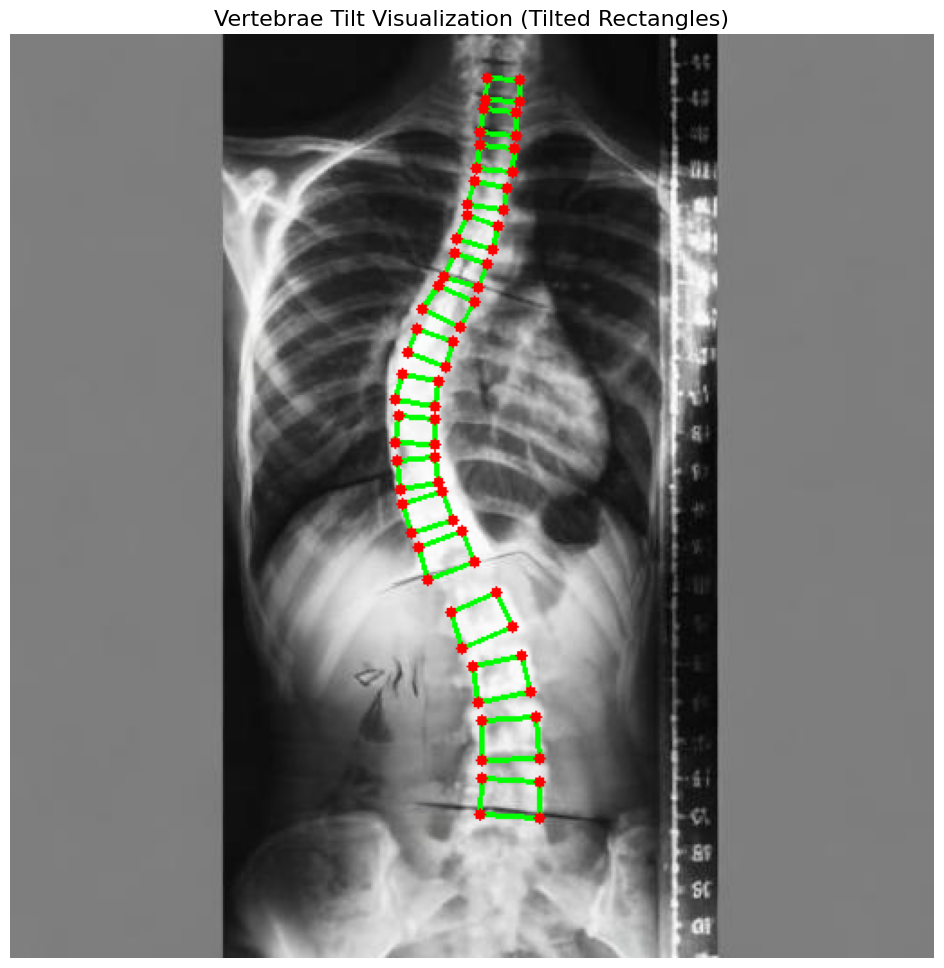

In [24]:
# CELL 8: Visualize a Prediction with Tilted Green Rectangles
import matplotlib.pyplot as plt
import random
import cv2
import numpy as np
from glob import glob

print("Fetching a random validation image...")

val_image_paths = glob(f"{VAL_IMAGES}/*.*") 
sample_image_path = random.choice(val_image_paths)

print(f"Testing on: {sample_image_path}")

# Run the trained model
results = v1_model.predict(source=sample_image_path, conf=0.5, save=False)

# 1. Get the original raw image array
orig_img = results[0].orig_img.copy()

# 2. Extract the keypoint coordinates (Shape: [Number of Vertebrae, 4, 2])
keypoints = results[0].keypoints.xy.cpu().numpy()

# 3. Draw green rectangles and red keypoints
for kpts in keypoints:
    if len(kpts) == 4:
        # Convert coordinates to integers for OpenCV
        pts = np.array(kpts, np.int32)
        
        # FIX: Use Convex Hull to reorder the 4 points and prevent the "bowtie" shape
        hull = cv2.convexHull(pts)
        
        # Draw the green tilted rectangle based on the hull outer boundary
        cv2.polylines(orig_img, [hull], isClosed=True, color=(0, 255, 0), thickness=2)
        
        # Draw the 4 keypoints as solid red dots
        for x, y in kpts:
            cv2.circle(orig_img, (int(x), int(y)), radius=3, color=(0, 0, 255), thickness=-1)

# Convert colors from BGR (OpenCV) to RGB (Matplotlib)
annotated_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(12, 12))
plt.imshow(annotated_img_rgb)
plt.axis('off')
plt.title("Vertebrae Tilt Visualization (Tilted Rectangles)", fontsize=16)
plt.show()

In [35]:
# CELL 9: Cobb Angle Calculation
import math
import numpy as np

def calculate_angle(pt1, pt2):
    """Calculates the angle of a line between two points in degrees."""
    dx = pt2[0] - pt1[0]
    dy = pt2[1] - pt1[1]
    if dx == 0:
        return 90.0
    return math.degrees(math.atan(dy / dx))

def get_cobb_angle(keypoints):
    """Finds the most tilted vertebrae and calculates the Cobb angle."""
    angles = []
    
    for kpts in keypoints:
        if len(kpts) == 4:
            # Sort the 4 points by Y-coordinate (top to bottom)
            sorted_kpts = sorted(kpts, key=lambda p: p[1])
            
            # The top two points form the upper endplate
            top_pt1, top_pt2 = sorted_kpts[0], sorted_kpts[1]
            # The bottom two points form the lower endplate
            bot_pt1, bot_pt2 = sorted_kpts[2], sorted_kpts[3]
            
            # Calculate angles for both plates and average them for the vertebra's general tilt
            top_angle = calculate_angle(top_pt1, top_pt2)
            bot_angle = calculate_angle(bot_pt1, bot_pt2)
            avg_tilt = (top_angle + bot_angle) / 2.0
            
            angles.append(avg_tilt)
    
    if len(angles) < 2:
        return 0.0
        
    # The Cobb angle is the difference between the maximum positive tilt and maximum negative tilt
    max_tilt = max(angles)
    min_tilt = min(angles)
    
    cobb_angle = abs(max_tilt - min_tilt)
    return cobb_angle

# Test it on the image from Cell 8
keypoints = results[0].keypoints.xy.cpu().numpy()
cobb_val = get_cobb_angle(keypoints)

print("==========================================================")
print(f"📐 CALCULATED COBB ANGLE: {cobb_val:.2f} degrees")
print("==========================================================")
if cobb_val > 10.0:
    print("[!] Clinical Note: Angle is > 10 degrees (Threshold for Scoliosis)")

📐 CALCULATED COBB ANGLE: 49.19 degrees
[!] Clinical Note: Angle is > 10 degrees (Threshold for Scoliosis)


In [36]:
# CELL 10: Generate Enhanced Dataset (Version 2)
import shutil
from tqdm import tqdm

print("🚀 STARTING CLAHE BATCH PROCESSING...")

CLAHE_BASE_DIR = "/kaggle/working/clahe_dataset"
os.makedirs(CLAHE_BASE_DIR, exist_ok=True)

# Define new paths
sets = ['train', 'val']
for s in sets:
    # Create new image directories
    new_img_dir = os.path.join(CLAHE_BASE_DIR, 'images', s)
    os.makedirs(new_img_dir, exist_ok=True)
    
    # Copy label directories exactly as they are (labels don't change, only images do)
    old_lbl_dir = os.path.join(DATASET_PATH, 'labels', s)
    new_lbl_dir = os.path.join(CLAHE_BASE_DIR, 'labels', s)
    if not os.path.exists(new_lbl_dir):
        shutil.copytree(old_lbl_dir, new_lbl_dir)
        
    # Process images
    old_img_dir = os.path.join(DATASET_PATH, 'images', s)
    images = glob(f"{old_img_dir}/*.*")
    
    print(f"Processing {len(images)} images for {s} set...")
    for img_path in tqdm(images):
        filename = os.path.basename(img_path)
        out_path = os.path.join(new_img_dir, filename)
        
        # Using the function you defined in Cell 4
        apply_clahe_to_image(img_path, out_path)

print(f"✅ CLAHE dataset generated at: {CLAHE_BASE_DIR}")

# Create a new YAML for V2 training
YAML_V2_PATH = os.path.join(BASE_DIR, "spine_keypoints_v2.yaml")
dataset_config_v2 = {
    'path': CLAHE_BASE_DIR,
    'train': os.path.join(CLAHE_BASE_DIR, 'images', 'train'),
    'val': os.path.join(CLAHE_BASE_DIR, 'images', 'val'),
    'nc': len(CLASSES),
    'names': CLASSES,
    'kpt_shape': KPT_SHAPE
}

with open(YAML_V2_PATH, 'w') as f:
    yaml.dump(dataset_config_v2, f, default_flow_style=False)
print(f"✅ Created V2 configuration at: {YAML_V2_PATH}")

🚀 STARTING CLAHE BATCH PROCESSING...
Processing 1255 images for train set...


100%|██████████| 1255/1255 [00:09<00:00, 135.22it/s]


Processing 745 images for val set...


100%|██████████| 745/745 [00:04<00:00, 152.51it/s]

✅ CLAHE dataset generated at: /kaggle/working/clahe_dataset
✅ Created V2 configuration at: /kaggle/working/spine_keypoints_v2.yaml


In [37]:
# CELL 11: Export to ONNX for Production
print("🚀 EXPORTING MODEL FOR BACKEND DEPLOYMENT...")

# Load the BEST weights from your V1 training run
best_weights_path = "/kaggle/working/runs/pose/Scoliosis_Detection/v1_yolov8n_baseline-2/weights/best.pt"
production_model = YOLO(best_weights_path)

# Export to ONNX format
# dynamic=True allows the model to accept different image sizes in production
export_path = production_model.export(format="onnx", dynamic=True)

print("==========================================================")
print(f"✅ MODEL EXPORTED SUCCESSFULLY!")
print(f"Path: {export_path}")
print("You can download this .onnx file from the Kaggle working directory")
print("and load it directly into a Node.js/Python backend.")
print("==========================================================")

🚀 EXPORTING MODEL FOR BACKEND DEPLOYMENT...
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-pose summary (fused): 82 layers, 3,077,771 parameters, 0 gradients, 8.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/pose/Scoliosis_Detection/v1_yolov8n_baseline-2/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 13, 5376) (6.1 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 272ms
Prepared 2 packages in 2.96s
Installed 2 packages in 28ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with on

In [39]:
# CELL 12: Clinical Report & Medical Recommendation
def get_severity(angle):
    if angle < 10: 
        return "Normal", "Routine Monitoring"
    elif 10 <= angle < 20: 
        return "Mild Scoliosis", "Physical therapy and 6-month follow-up."
    elif 20 <= angle < 40: 
        return "Moderate Scoliosis", "Bracing or specialized orthotic consultation suggested."
    else: 
        return "Severe Scoliosis", "High Severity: Urgent surgical/orthopedic consultation required."

# Generate classification and advice
severity_label, recommendation = get_severity(cobb_val)

# Final Structured Report
clinical_report = {
    "Patient ID": "ANANT_P_57",
    "Cobb Angle": f"{round(cobb_val, 2)}°",
    "Classification": severity_label,
    "Vertebrae Detected": len(keypoints),
    "Reliability": "High" if len(keypoints) >= 12 else "Low (Partial Scan)",
    "Recommendation": recommendation
}

print("==========================================================")
print("🩺 FINAL CLINICAL DIAGNOSTIC REPORT")
print("==========================================================")
for key, value in clinical_report.items():
    print(f"{key:.<25} {value}")
print("==========================================================")

# Save to JSON for backend integration
with open('/kaggle/working/final_report.json', 'w') as f:
    json.dump(clinical_report, f, indent=4)

🩺 FINAL CLINICAL DIAGNOSTIC REPORT
Patient ID............... ANANT_P_57
Cobb Angle............... 49.19°
Classification........... Severe Scoliosis
Vertebrae Detected....... 17
Reliability.............. High
Recommendation........... High Severity: Urgent surgical/orthopedic consultation required.


In [12]:
# Check the exact shape of your dataset labels
label_path = '/kaggle/input/datasets/adwayne/yolo-data/scoliosis_fixed/labels/train/000005.txt'

with open(label_path, 'r') as f:
    line = f.readline().strip()
    columns = line.split()
    print(f"Number of columns in label: {len(columns)}")
    print(f"Raw data: {line}")

Number of columns in label: 13
Raw data: 0 0.533203 0.086914 0.035156 0.025391  0.519531 0.076172  0.550781 0.076172  0.517578 0.097656  0.550781 0.099609


In [41]:
# CELL 15: Space Cleanup
import shutil
import os

# 1. Delete the heavy CLAHE dataset (you've already trained your model, so you don't need the raw images anymore)
clahe_dir = "/kaggle/working/clahe_dataset"
if os.path.exists(clahe_dir):
    shutil.rmtree(clahe_dir)
    print(f"✅ Deleted {clahe_dir} to free up space.")

# 2. Delete any failed/partial zip files
for file in os.listdir("/kaggle/working"):
    if file.endswith(".zip"):
        os.remove(os.path.join("/kaggle/working", file))
        print(f"✅ Removed partial zip: {file}")

print("\n🚀 Space cleaned! Check your 'Output' meter on the right.")

✅ Deleted /kaggle/working/clahe_dataset to free up space.
✅ Removed partial zip: scoliosis_results.zip
✅ Removed partial zip: scoliosis_project_full_output.zip
✅ Removed partial zip: complete_working_directory.zip

🚀 Space cleaned! Check your 'Output' meter on the right.


In [42]:
# CELL 16: Zip only the 'runs' folder for download
import shutil
import os

# Define the name of the zip file
zip_name = "scoliosis_runs_output"
# The specific directory you want to zip
dir_to_zip = "/kaggle/working/runs"

if os.path.exists(dir_to_zip):
    print(f"🚀 Zipping {dir_to_zip}...")
    shutil.make_archive(zip_name, 'zip', dir_to_zip)
    print(f"✅ Success! Your file is ready: {zip_name}.zip")
else:
    print(f"❌ Error: {dir_to_zip} not found. Please run the training cell first.")

🚀 Zipping /kaggle/working/runs...
✅ Success! Your file is ready: scoliosis_runs_output.zip
